# DDPM Tasks 6-7



In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from sklearn.datasets import make_moons

from src.train import load_ddpm_checkpoint, train_ddpm
from src.eval import (
    run_task7_diagnostics,
    run_task7_full_evaluation,
    run_task6_ablation,
    run_task6_timestep_ablation,
    sliced_wasserstein_distance_2d,
    rbf_mmd_2d,
    save_toy_scatter,
)

sns.set_theme(style="whitegrid")


## Train (or reuse) Task 7 model checkpoint

Task 7 training below is pinned to the exact Task 4 setup (same schedule/training args and same TinyUNet config).

In [27]:
TASK7_CKPT = Path("outputs/checkpoints/tiny_unet_mnist_task7_eval_deep.pt")
RUN_TASK7_TRAIN = True  # set False to reuse existing Task 7 checkpoint

TASK4_STEPS = 4000
TASK4_BATCH_SIZE = 128
TASK4_SAMPLE_EVERY = 3500
TASK4_UNET_VARIANT = "deep"
TASK4_UNET_TIME_DIM = 256
TASK4_UNET_BASE_CHANNELS = 64

if RUN_TASK7_TRAIN or (not TASK7_CKPT.exists()):
    model_d, schedule_d, losses_d, task7_train_stats = train_ddpm(
        steps=TASK4_STEPS,
        batch_size=TASK4_BATCH_SIZE,
        sample_every=TASK4_SAMPLE_EVERY,
        unet_variant=TASK4_UNET_VARIANT,
        unet_time_dim=TASK4_UNET_TIME_DIM,
        unet_base_channels=TASK4_UNET_BASE_CHANNELS,
        checkpoint_path=TASK7_CKPT,
        return_stats=True,
    )
    print("Task 7 training done (Task-4 deep setup). Last loss:", losses_d[-1])
    print("Saved checkpoint:", TASK7_CKPT)
    print("Periodic sample grids:")
    for p in task7_train_stats["sample_paths"]:
        print(" -", p)
else:
    model_d, schedule_d = load_ddpm_checkpoint(TASK7_CKPT)
    losses_d = []
    task7_train_stats = {"sample_paths": []}
    print("Loaded Task 7 checkpoint:", TASK7_CKPT)


Task 4 Training:   0%|          | 0/4000 [00:00<?, ?it/s]

Task 7 training done (Task-4 deep setup). Last loss: 0.025583242997527122
Saved checkpoint: outputs\checkpoints\tiny_unet_mnist_task7_eval_deep.pt
Periodic sample grids:
 - C:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\outputs\samples\train_step_003500.png


## Task 7: Qualitative artifacts (fixed-seed trajectory)


In [28]:
if len(losses_d) == 0:
    print("No in-memory training losses (checkpoint loaded). Using placeholder for loss curve artifact.")
    losses_for_diag = [0.0]
else:
    losses_for_diag = losses_d

diagnostic_paths = run_task7_diagnostics(model_d, schedule_d, losses_for_diag)
diagnostic_paths


{'loss_curve': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\figures\\task7_loss_curve.png',
 'sample_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\samples\\task7_samples.png',
 'trajectory': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\samples\\task7_trajectory.png'}

## Task 7: Full quantitative evaluation (pages 16-18)

In [29]:
task7_results = run_task7_full_evaluation(
    model=model_d,
    schedule=schedule_d,
    losses=losses_for_diag,
    num_samples=512,
    metrics_real_samples=1024,
    nn_train_samples=5000,
    classifier_epochs=1,
    elbo_num_batches=2,
    elbo_timestep_stride=100,
)
task7_results


c:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\src\eval.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_pat

{'loss_curve': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\figures\\task7_loss_curve.png',
 'sample_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\samples\\task7_samples.png',
 'trajectory': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\samples\\task7_trajectory.png',
 'nearest_neighbor_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\figures\\task7_nearest_neighbors.png',
 'classifier_test_accuracy': 0.9736328125,
 'classifier_feature_extractor_checkpoint': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\checkpoints\\mnist_eval_classifier.pt',
 'classifier_feature_extractor_retrained_now': 0.0,
 'feature_fid_test': 40.386234363000966,
 'feature_fid_train': 36.907499617285346,
 'feature_kid_test': 10.597069248482129,
 'feature_kid_train': 15.779563866060759,
 'feat

In [30]:
task7_df = pd.DataFrame([task7_results])
display(task7_df.T.rename(columns={0: "value"}))

task7_plot_cols = [
    c for c in [
        "feature_fid_test",
        "feature_kid_test",
        "generated_class_entropy_normalized",
        "generated_mean_confidence",
        "bpd_mean",
    ]
    if c in task7_df.columns
]

,value
loss_curve,C:\Users\ahmad\Documents\GitHub\Learning Diffu...
sample_grid,C:\Users\ahmad\Documents\GitHub\Learning Diffu...
trajectory,C:\Users\ahmad\Documents\GitHub\Learning Diffu...
nearest_neighbor_grid,C:\Users\ahmad\Documents\GitHub\Learning Diffu...
classifier_test_accuracy,0.973633
classifier_feature_extractor_checkpoint,C:\Users\ahmad\Documents\GitHub\Learning Diffu...
classifier_feature_extractor_retrained_now,0.0
feature_fid_test,40.386234
feature_fid_train,36.9075
feature_kid_test,10.597069


## Task 6: Schedule ablation (linear vs cosine)


In [36]:
ablation_results = run_task6_ablation(
    train_steps=1500,
    timesteps=1500,
    num_samples=128,
    metrics_real_samples=1024,
    nn_train_samples=5000,
    classifier_epochs=1,
    elbo_num_batches=2,
    elbo_timestep_stride=100,
)
ablation_results


c:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\src\eval.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_pat

Task 4 Training:   0%|          | 0/1500 [00:00<?, ?it/s]

Task 4 Training:   0%|          | 0/1500 [00:00<?, ?it/s]

[{'name': 'linear',
  'schedule_type': 'linear',
  'unet_variant': 'legacy',
  'unet_time_dim': 128.0,
  'unet_base_channels': 32.0,
  'beta_end': 0.02,
  'final_loss': 0.03456984832882881,
  'sample_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\samples\\task6_linear_samples.png',
  'nearest_neighbor_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\figures\\task6_linear_nearest_neighbors.png',
  'classifier_test_accuracy': 0.9736328125,
  'classifier_feature_extractor_checkpoint': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\checkpoints\\mnist_eval_classifier.pt',
  'classifier_feature_extractor_retrained_now': 0.0,
  'feature_fid_test': 424.85058918387784,
  'feature_fid_train': 408.07677038731157,
  'feature_kid_test': 177.6974646477056,
  'feature_kid_train': 168.57464708702776,
  'feature_fid_train_minus_test': -16.773818796566275,
  'feature_

In [ ]:
ablation_df = pd.DataFrame(ablation_results)
schedule_table_cols = [
    c for c in [
        "name",
        "schedule_type",
        "final_loss",
        "feature_fid_test",
        "feature_kid_test",
        "generated_class_entropy_normalized",
        "generated_mean_confidence",
        "bpd_mean",
    ]
    if c in ablation_df.columns
]
display(ablation_df[schedule_table_cols].sort_values("feature_fid_test"))

schedule_plot_cols = [c for c in ["feature_fid_test", "feature_kid_test", "bpd_mean", "final_loss"] if c in ablation_df.columns]
if len(schedule_plot_cols) > 0:
    plot_df = ablation_df.melt(id_vars=["name"], value_vars=schedule_plot_cols, var_name="metric", value_name="value")
    g = sns.catplot(data=plot_df, kind="bar", x="name", y="value", col="metric", sharey=False, height=3.2, aspect=1.0)
    g.fig.suptitle("Task 6 Schedule Ablation Comparison", y=1.05)
    plt.show()


,name,schedule_type,final_loss,feature_fid_test,feature_kid_test,generated_class_entropy_normalized,generated_mean_confidence,bpd_mean
1,cosine,cosine,0.05231,321.542382,156.348325,0.940332,0.723998,30.912289
0,linear,linear,0.03457,424.850589,177.697465,0.917512,0.661643,38.975632


## Task 6: Timestep-count ablation

Retrains with different diffusion lengths `L` (same model architecture).


In [33]:
timestep_ablation_results = run_task6_timestep_ablation(
    timestep_values=(1000, 500, 250),
    train_steps=250,
    num_samples=128,
    metrics_real_samples=1024,
    nn_train_samples=5000,
    classifier_epochs=1,
    elbo_num_batches=2,
    elbo_timestep_stride=100,
)
timestep_ablation_results


c:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\src\eval.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_pat

Task 4 Training:   0%|          | 0/250 [00:00<?, ?it/s]

Task 4 Training:   0%|          | 0/250 [00:00<?, ?it/s]

Task 4 Training:   0%|          | 0/250 [00:00<?, ?it/s]

[{'name': 't1000',
  'timesteps': 1000.0,
  'schedule_type': 'linear',
  'unet_variant': 'legacy',
  'unet_time_dim': 128.0,
  'unet_base_channels': 32.0,
  'final_loss': 0.05120060592889786,
  'sample_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\samples\\task6_timestep_t1000_samples.png',
  'nearest_neighbor_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\figures\\task6_timestep_t1000_nearest_neighbors.png',
  'classifier_test_accuracy': 0.9736328125,
  'classifier_feature_extractor_checkpoint': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\checkpoints\\mnist_eval_classifier.pt',
  'classifier_feature_extractor_retrained_now': 0.0,
  'feature_fid_test': 579.3982837285055,
  'feature_fid_train': 592.2439867769973,
  'feature_kid_test': 215.86226298628966,
  'feature_kid_train': 225.8279429996725,
  'feature_fid_train_minus_test': 12.8457030484918

,name,timesteps,final_loss,feature_fid_test,feature_kid_test,generated_class_entropy_normalized,generated_mean_confidence,bpd_mean
0,t1000,1000.0,0.051201,579.398284,215.862263,0.871591,0.622285,72.365067
1,t500,500.0,0.077432,569.953361,211.029368,0.910381,0.622318,83.631172
2,t250,250.0,0.108000,658.632148,226.563558,0.922518,0.543542,79.842972


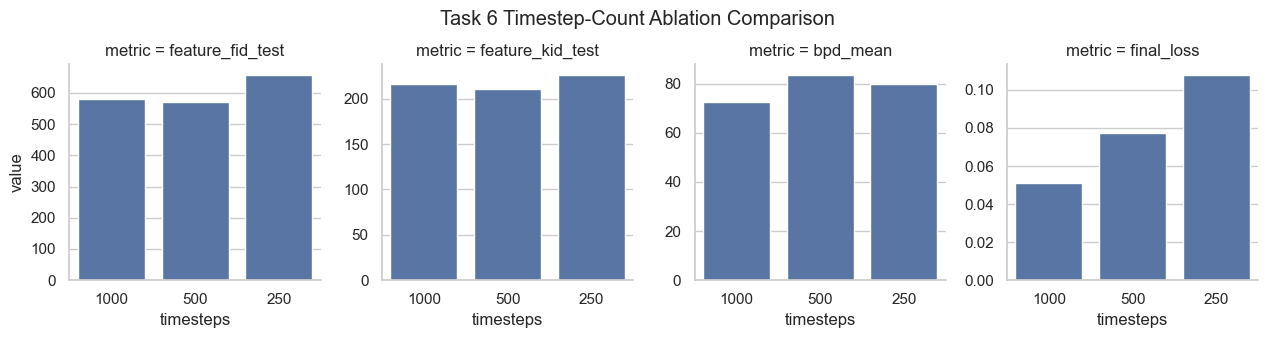

In [34]:
timestep_df = pd.DataFrame(timestep_ablation_results).sort_values("timesteps", ascending=False)
timestep_table_cols = [
    c for c in [
        "name",
        "timesteps",
        "final_loss",
        "feature_fid_test",
        "feature_kid_test",
        "generated_class_entropy_normalized",
        "generated_mean_confidence",
        "bpd_mean",
    ]
    if c in timestep_df.columns
]
display(timestep_df[timestep_table_cols])

timestep_plot_cols = [c for c in ["feature_fid_test", "feature_kid_test", "bpd_mean", "final_loss"] if c in timestep_df.columns]
if len(timestep_plot_cols) > 0:
    plot_df = timestep_df.melt(id_vars=["timesteps"], value_vars=timestep_plot_cols, var_name="metric", value_name="value")
    plot_df["timesteps"] = plot_df["timesteps"].astype(int).astype(str)
    g = sns.catplot(data=plot_df, kind="bar", x="timesteps", y="value", col="metric", sharey=False, height=3.2, aspect=1.0)
    g.fig.suptitle("Task 6 Timestep-Count Ablation Comparison", y=1.05)
    plt.show()


## 2D toy metrics utilities (Task C)


In [35]:
toy_real_np, _ = make_moons(n_samples=1000, noise=0.05, random_state=42)
toy_generated_np = toy_real_np + 0.08 * torch.randn(1000, 2).numpy()

toy_real = torch.tensor(toy_real_np, dtype=torch.float32)
toy_generated = torch.tensor(toy_generated_np, dtype=torch.float32)

toy_swd = sliced_wasserstein_distance_2d(toy_real, toy_generated, num_projections=64)
toy_mmd = rbf_mmd_2d(toy_real, toy_generated, sigma=0.2)
toy_plot_path = save_toy_scatter(toy_real, toy_generated)

print("toy_swd:", toy_swd)
print("toy_rbf_mmd:", toy_mmd)
print("toy_scatter:", toy_plot_path)


toy_swd: 0.015013711696387684
toy_rbf_mmd: 0.0012056032204061373
toy_scatter: C:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\outputs\figures\task6_toy_scatter.png
